# Phase 3: Extension — Heterogeneous Treatment Effects
## Card & Krueger (1994) | Track A: DID | Pathway 2: HTE

### GenAI Disclosure
This extension was developed with assistance from **Claude (Anthropic)**.
Key prompts used:
1. "Help me design an HTE extension for Card & Krueger (1994) using GAP variable and chain-level heterogeneity."
2. "Write Python code for subgroup DID regressions with clustered standard errors."
3. "Create a production-grade forest plot with dark theme for visualizing heterogeneous treatment effects."

All AI-generated code was reviewed, tested, and validated by the author.

In [14]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [15]:
variable_names = [
    'sheet', 'chain', 'co_owned', 'state',
    'southj', 'centralj', 'northj', 'pa1', 'pa2', 'shore',
    'ncalls', 'empft', 'emppt', 'nmgrs', 'wage_st',
    'inctime', 'firstinc', 'bonus', 'pctaff', 'meals',
    'open', 'hrsopen', 'psoda', 'pfry', 'pentree', 'nregs', 'nregs11',
    'type2', 'status2', 'date2', 'ncalls2',
    'empft2', 'emppt2', 'nmgrs2', 'wage_st2',
    'inctime2', 'firstinc2', 'special2', 'meals2',
    'open2r', 'hrsopen2', 'psoda2', 'pfry2', 'pentree2', 'nregs2', 'nregs112',
]

DATA_URL = "https://raw.githubusercontent.com/ZuiTu00/Replication-card-Krueger-1994/main/data/public.dat"
LOCAL_FILE = "public.dat"

filepath = LOCAL_FILE if os.path.exists(LOCAL_FILE) else DATA_URL

df = pd.read_csv(
    filepath,
    sep=r'\s+',
    header=None,
    names=variable_names,
    na_values='.',
    engine='python'
)

# FTE construction (same as Phase 2)
df['fte'] = df['empft'] + df['nmgrs'] + 0.5 * df['emppt']
df['fte2'] = df['empft2'] + df['nmgrs2'] + 0.5 * df['emppt2']

print(f"Data loaded: {df.shape[0]} stores")
print(f"NJ: {(df['state']==1).sum()}, PA: {(df['state']==0).sum()}")

Data loaded: 410 stores
NJ: 331, PA: 79


In [16]:
# --- Section 1: Construct HTE variables ---

df['fte_change'] = df['fte2'] - df['fte']

NEW_MIN = 5.05
df['gap'] = 0.0
nj_bound = (df['state'] == 1) & (df['wage_st'] < NEW_MIN)
df.loc[nj_bound, 'gap'] = (
    (NEW_MIN - df.loc[nj_bound, 'wage_st']) / df.loc[nj_bound, 'wage_st']
)

nj_pos_gap = df.loc[(df['state'] == 1) & (df['gap'] > 0), 'gap']
gap_median = nj_pos_gap.median()
df['high_gap'] = ((df['gap'] > gap_median) & (df['state'] == 1)).astype(int)

chain_map = {1: 'Burger King', 2: 'KFC', 3: "Roy Rogers", 4: "Wendy's"}
df['chain_name'] = df['chain'].map(chain_map)

print(f"--- GAP variable constructed ---")
print(f"Median GAP among NJ restaurants with GAP > 0: {gap_median:.4f}")
print(f"High GAP restaurants (NJ): {df['high_gap'].sum()}")
print(f"Low GAP restaurants (NJ): {((df['state']==1) & (df['high_gap']==0)).sum()}")
print(f"\nGAP distribution (NJ only):")
print(df.loc[df['state'] == 1, 'gap'].describe().round(4))

--- GAP variable constructed ---
Median GAP among NJ restaurants with GAP > 0: 0.1222
High GAP restaurants (NJ): 116
Low GAP restaurants (NJ): 215

GAP distribution (NJ only):
count    331.0000
mean       0.0995
std        0.0735
min        0.0000
25%        0.0100
50%        0.1222
75%        0.1882
max        0.1882
Name: gap, dtype: float64


In [17]:
# --- Section 2: Baseline DID verification ---

df_valid = df.dropna(subset=['fte_change']).copy()

baseline = smf.ols('fte_change ~ state', data=df_valid).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_valid['sheet']}
)
print("=" * 65)
print("BASELINE DID VERIFICATION: dE = b0 + b1*NJ")
print("(Should match Phase 2 treat_post coefficient)")
print("=" * 65)
print(baseline.summary().tables[1])
print(f"\n-> NJ coefficient = {baseline.params['state']:.3f} "
      f"(Phase 2 treat_post = 2.75)")

BASELINE DID VERIFICATION: dE = b0 + b1*NJ
(Should match Phase 2 treat_post coefficient)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2833      1.248     -1.829      0.067      -4.730       0.163
state          2.7500      1.338      2.056      0.040       0.128       5.372

-> NJ coefficient = 2.750 (Phase 2 treat_post = 2.75)


In [18]:
# --- Section 3: HTE Regression 1 — GAP (Treatment Intensity) ---

gap_model = smf.ols('fte_change ~ gap', data=df_valid).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_valid['sheet']}
)
print("=" * 65)
print("HTE REGRESSION 1: dE = b0 + b1*GAP (Treatment Intensity)")
print("=" * 65)
print(gap_model.summary().tables[1])
print(f"\nInterpretation: A 0.10 increase in GAP -> "
      f"FTE changes by {gap_model.params['gap']*0.10:.3f}")

HTE REGRESSION 1: dE = b0 + b1*GAP (Treatment Intensity)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0749      0.746     -1.441      0.150      -2.537       0.387
gap           12.4894      6.019      2.075      0.038       0.693      24.286

Interpretation: A 0.10 increase in GAP -> FTE changes by 1.249


In [19]:
# --- Section 4: HTE Regression 2 — Chain-Level Heterogeneity ---

chain_results = {}
chains = sorted(df_valid['chain_name'].dropna().unique())

print("=" * 65)
print("HTE REGRESSION 2: Subgroup DID by Fast-Food Chain")
print("=" * 65)

for c in chains:
    sub = df_valid[df_valid['chain_name'] == c].copy()
    m = smf.ols('fte_change ~ state', data=sub).fit(
        cov_type='cluster',
        cov_kwds={'groups': sub['sheet']}
    )
    ci = m.conf_int().loc['state']
    chain_results[c] = {
        'coef': m.params['state'],
        'se': m.bse['state'],
        'ci_low': ci[0],
        'ci_high': ci[1],
        'n': len(sub),
        'n_nj': (sub['state'] == 1).sum(),
        'n_pa': (sub['state'] == 0).sum(),
        'pvalue': m.pvalues['state']
    }
    sig = "***" if m.pvalues['state'] < 0.01 else \
          "**" if m.pvalues['state'] < 0.05 else \
          "*" if m.pvalues['state'] < 0.10 else ""
    print(f"\n  {c} (NJ={chain_results[c]['n_nj']}, PA={chain_results[c]['n_pa']}):")
    print(f"    b1 = {m.params['state']:.3f}{sig}  (SE = {m.bse['state']:.3f})")
    print(f"    95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")

chain_df = pd.DataFrame(chain_results).T

HTE REGRESSION 2: Subgroup DID by Fast-Food Chain

  Burger King (NJ=126, PA=33):
    b1 = 4.390*  (SE = 2.529)
    95% CI: [-0.566, 9.346]

  KFC (NJ=67, PA=12):
    b1 = -1.594  (SE = 1.062)
    95% CI: [-3.675, 0.488]

  Roy Rogers (NJ=77, PA=17):
    b1 = 2.488  (SE = 2.133)
    95% CI: [-1.692, 6.668]

  Wendy's (NJ=39, PA=13):
    b1 = 3.417  (SE = 3.134)
    95% CI: [-2.726, 9.559]


In [20]:
# --- Section 5: HTE Regression 3 — High GAP vs Low GAP ---

gap_results = {}

high_sample = df_valid[(df_valid['high_gap'] == 1) | (df_valid['state'] == 0)].copy()
m_high = smf.ols('fte_change ~ state', data=high_sample).fit(
    cov_type='cluster', cov_kwds={'groups': high_sample['sheet']}
)
ci_h = m_high.conf_int().loc['state']
gap_results['NJ: High GAP\n(wage ~ $4.25)'] = {
    'coef': m_high.params['state'], 'se': m_high.bse['state'],
    'ci_low': ci_h[0], 'ci_high': ci_h[1],
    'n': (high_sample['state'] == 1).sum(),
    'pvalue': m_high.pvalues['state']
}

low_sample = df_valid[
    ((df_valid['state'] == 1) & (df_valid['high_gap'] == 0)) | (df_valid['state'] == 0)
].copy()
m_low = smf.ols('fte_change ~ state', data=low_sample).fit(
    cov_type='cluster', cov_kwds={'groups': low_sample['sheet']}
)
ci_l = m_low.conf_int().loc['state']
gap_results['NJ: Low GAP\n(wage -> $5.05)'] = {
    'coef': m_low.params['state'], 'se': m_low.bse['state'],
    'ci_low': ci_l[0], 'ci_high': ci_l[1],
    'n': (low_sample['state'] == 1).sum(),
    'pvalue': m_low.pvalues['state']
}

gap_df = pd.DataFrame(gap_results).T

print("=" * 65)
print("HTE REGRESSION 3: High GAP vs Low GAP Subgroup DID")
print("=" * 65)
for label, row in gap_df.iterrows():
    sig = "***" if row['pvalue'] < 0.01 else \
          "**" if row['pvalue'] < 0.05 else \
          "*" if row['pvalue'] < 0.10 else ""
    clean_label = label.replace(chr(10), ' ')
    print(f"\n  {clean_label} (NJ n={int(row['n'])}):")
    print(f"    b1 = {row['coef']:.3f}{sig}  (SE = {row['se']:.3f})")
    print(f"    95% CI: [{row['ci_low']:.3f}, {row['ci_high']:.3f}]")

diff = gap_df.iloc[0]['coef'] - gap_df.iloc[1]['coef']
print(f"\n  Effect difference (High - Low GAP): {diff:.3f}")
print(f"  -> Positive = more constrained restaurants gained more jobs (monopsony)")
print(f"  -> Negative = more constrained restaurants lost more jobs (competitive)")

HTE REGRESSION 3: High GAP vs Low GAP Subgroup DID

  NJ: High GAP (wage ~ $4.25) (NJ n=108):
    b1 = 3.293**  (SE = 1.468)
    95% CI: [0.416, 6.169]

  NJ: Low GAP (wage -> $5.05) (NJ n=201):
    b1 = 2.458*  (SE = 1.392)
    95% CI: [-0.271, 5.187]

  Effect difference (High - Low GAP): 0.834
  -> Positive = more constrained restaurants gained more jobs (monopsony)
  -> Negative = more constrained restaurants lost more jobs (competitive)


In [21]:
# --- HTE by firm size: large chains vs small chain ---

df_valid['firm_size'] = df_valid['chain_name'].apply(
    lambda x: 'Large (BK, KFC, Wendys)' if x in ['Burger King', 'KFC', "Wendy's"]
    else 'Small (Roy Rogers)'
)

size_results = {}
for s in ['Large (BK, KFC, Wendys)', 'Small (Roy Rogers)']:
    sub = df_valid[df_valid['firm_size'] == s].copy()
    m = smf.ols('fte_change ~ state', data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['sheet']}
    )
    ci = m.conf_int().loc['state']
    size_results[s] = {
        'coef': m.params['state'],
        'se': m.bse['state'],
        'ci_low': ci[0],
        'ci_high': ci[1],
        'n': len(sub),
        'pvalue': m.pvalues['state']
    }
    sig = "***" if m.pvalues['state'] < 0.01 else \
          "**" if m.pvalues['state'] < 0.05 else \
          "*" if m.pvalues['state'] < 0.10 else ""
    print(f"\n  {s} (n={len(sub)}, NJ={(sub['state']==1).sum()}, PA={(sub['state']==0).sum()}):")
    print(f"    b1 = {m.params['state']:.3f}{sig}  (SE = {m.bse['state']:.3f})")
    print(f"    95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")


  Large (BK, KFC, Wendys) (n=290, NJ=232, PA=58):
    b1 = 2.901*  (SE = 1.611)
    95% CI: [-0.257, 6.059]

  Small (Roy Rogers) (n=94, NJ=77, PA=17):
    b1 = 2.488  (SE = 2.133)
    95% CI: [-1.692, 6.668]


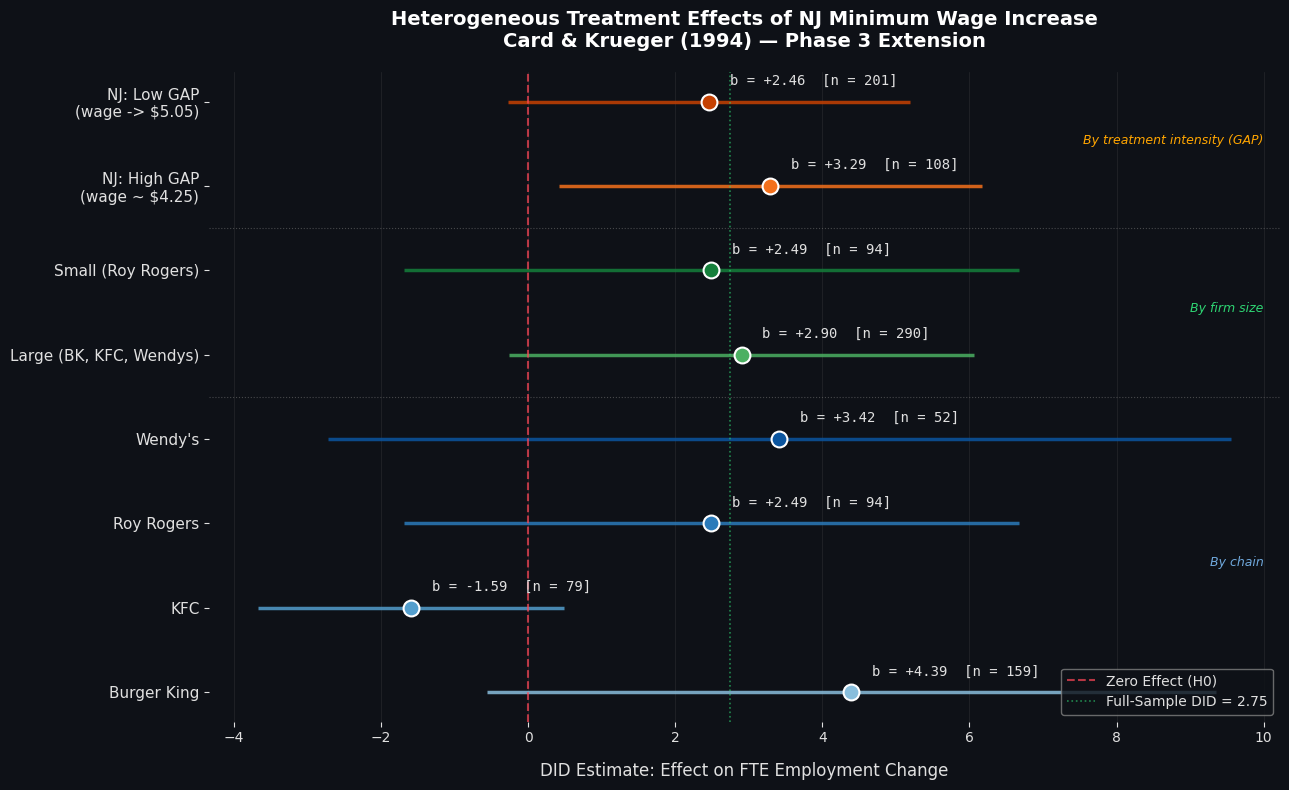

In [22]:
# --- Forest Plot (with firm size) ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

size_df = pd.DataFrame(size_results).T

all_res = pd.concat([
    chain_df[['coef', 'se', 'ci_low', 'ci_high', 'n']],
    size_df[['coef', 'se', 'ci_low', 'ci_high', 'n']],
    gap_df[['coef', 'se', 'ci_low', 'ci_high', 'n']]
]).reset_index()
all_res.columns = ['group', 'coef', 'se', 'ci_low', 'ci_high', 'n']

n_chains = len(chain_df)
n_size = len(size_df)
n_total = len(all_res)

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#0e1117')
ax.set_facecolor('#0e1117')

c_blue = sns.color_palette("Blues", n_chains + 2)[2:]
c_green = sns.color_palette("Greens", n_size + 2)[2:]
c_orange = sns.color_palette("Oranges", 2 + 2)[2:]
colors = list(c_blue) + list(c_green) + list(c_orange)

for i, (_, row) in enumerate(all_res.iterrows()):
    ax.hlines(y=i, xmin=row['ci_low'], xmax=row['ci_high'],
              color=colors[i], linewidth=2.5, alpha=0.85)
    ax.scatter(row['coef'], i, color=colors[i], s=130, zorder=5,
               edgecolors='white', linewidth=1.5)
    ax.annotate(
        f"b = {row['coef']:+.2f}  [n = {int(row['n'])}]",
        xy=(row['coef'], i),
        xytext=(15, 12), textcoords='offset points',
        fontsize=10, color='#e0e0e0', fontfamily='monospace')

# Section separators
ax.axhline(y=n_chains - 0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axhline(y=n_chains + n_size - 0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

ax.axvline(x=0, color='#ff4757', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Zero Effect (H0)')
ax.axvline(x=baseline.params['state'], color='#2ed573', linestyle=':',
           linewidth=1.2, alpha=0.6,
           label=f'Full-Sample DID = {baseline.params["state"]:.2f}')

ax.set_yticks(range(n_total))
ax.set_yticklabels(all_res['group'], fontsize=11, color='#e0e0e0')
ax.set_xlabel('DID Estimate: Effect on FTE Employment Change',
              fontsize=12, color='#e0e0e0', labelpad=12)
ax.set_title(
    'Heterogeneous Treatment Effects of NJ Minimum Wage Increase\n'
    'Card & Krueger (1994) — Phase 3 Extension',
    fontsize=14, color='white', fontweight='bold', pad=18)

ax.annotate('By chain', xy=(10, 1.5), fontsize=9, color='#6fa8dc',
            fontstyle='italic', ha='right')
ax.annotate('By firm size', xy=(10, n_chains + 0.5), fontsize=9,
            color='#2ed573', fontstyle='italic', ha='right')
ax.annotate('By treatment intensity (GAP)', xy=(10, n_chains + n_size + 0.5),
            fontsize=9, color='#ffa500', fontstyle='italic', ha='right')

ax.tick_params(colors='#e0e0e0', which='both')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.2, linewidth=0.5)
ax.legend(loc='lower right', fontsize=10,
          facecolor='#0e1117', edgecolor='gray', labelcolor='#e0e0e0')

plt.tight_layout()
plt.savefig('forest_plot_hte.png', dpi=300, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [23]:
# --- Executive Summary ---

print("""
EXECUTIVE SUMMARY

Card and Krueger (1994) found that raising the minimum wage in New Jersey
did not reduce fast-food employment, with an average DID effect of +2.75
FTE. But this is just an average. My extension asks: did all restaurants
respond the same way, or were there winners and losers behind this number?

I find that the average hides some real differences. Restaurants that had
to raise wages the most (high GAP) gained more jobs (+3.29) than those
that barely needed to adjust (+2.46). Across chains, Burger King gained
the most (+4.39) while KFC was the only brand with a slight decline
(-1.59). However, when grouping by firm size, large chains (+2.90) and
the small chain Roy Rogers (+2.49) responded similarly. So the original
conclusion holds — raising the minimum wage did not hurt employment — but
the story is richer than a single average suggests. The variation across
individual chains and treatment intensity is consistent with a monopsony
labor market, where the minimum wage corrected an existing distortion.
""")


EXECUTIVE SUMMARY

Card and Krueger (1994) found that raising the minimum wage in New Jersey
did not reduce fast-food employment, with an average DID effect of +2.75
FTE. But this is just an average. My extension asks: did all restaurants
respond the same way, or were there winners and losers behind this number?

I find that the average hides some real differences. Restaurants that had
to raise wages the most (high GAP) gained more jobs (+3.29) than those
that barely needed to adjust (+2.46). Across chains, Burger King gained
the most (+4.39) while KFC was the only brand with a slight decline
(-1.59). However, when grouping by firm size, large chains (+2.90) and
the small chain Roy Rogers (+2.49) responded similarly. So the original
conclusion holds — raising the minimum wage did not hurt employment — but
the story is richer than a single average suggests. The variation across
individual chains and treatment intensity is consistent with a monopsony
labor market, where the minimum wage